# 1. Getting started: coverage from one image

What this notebook does: run the canopy pipeline on a single local image and
read the result honestly -- what the number means, what it does *not* mean, and
which parts of the output exist so you can check the model rather than trust it.

**No Google API key and no GPU are needed.** It runs on the images in
`samples/images/`.

Setup, from the repository root:

```bash
python -m pip install -e ".[ml,notebooks]"
```

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Repository root, whether the notebook is opened from notebooks/ or from root.
ROOT = Path.cwd()
if not (ROOT / "samples").exists():
    ROOT = ROOT.parent
SAMPLES = ROOT / "samples" / "images"

# "oneformer" downloads ~1.7 GB on first use; "mask2former" ~850 MB and is
# otherwise interchangeable here. "detectron2" needs a compiled install
# (see docs/detectron2-windows.md); "deeplab" needs a Cityscapes checkpoint
# and reports vegetation only, since that class space has no tree class.
BACKEND = "oneformer"

import torch
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE, "| backend:", BACKEND)
print("samples:", len(list(SAMPLES.glob("*.jpg"))), "images")

device: cuda | backend: oneformer
samples: 7 images


## The image

`streetview_id1_heading0.jpg` is the heaviest-canopy frame in the sample set.

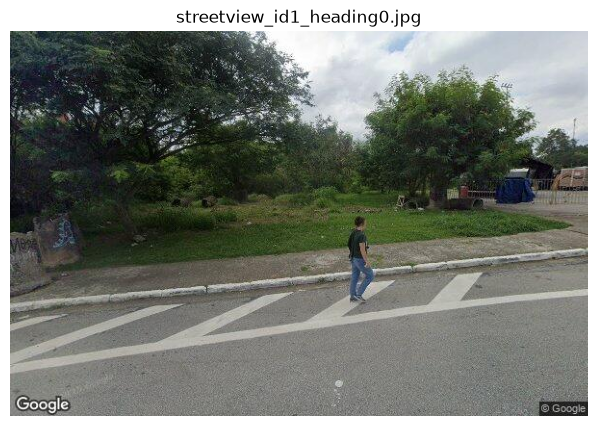

shape: (400, 600, 3)


In [2]:
from urban_canopy.io.image_io import read_rgb

image_path = SAMPLES / "streetview_id1_heading0.jpg"
rgb = read_rgb(image_path)

plt.figure(figsize=(8, 5))
plt.imshow(rgb)
plt.axis("off")
plt.title(image_path.name)
plt.show()

print("shape:", rgb.shape)

## Build the pipeline

Two objects: a segmentation backend, and a `CanopyPipeline` that wraps it with
the configuration that can move a number (refinement and whether a
vegetation proxy is allowed). Coverage always uses the complete image.

Loading the model takes a while the first time; the weights are cached
afterwards.

In [3]:
from urban_canopy.core.config import CanopyConfig
from urban_canopy.core.pipeline import CanopyPipeline
from urban_canopy.models.factory import build_segmenter

segmenter = build_segmenter(BACKEND, device=DEVICE)
pipeline = CanopyPipeline(segmenter=segmenter, config=CanopyConfig())

print("class space:", segmenter.class_space)
print("tree group :", segmenter.taxonomy.tree_group)
print("counted as vegetation:", segmenter.taxonomy.vegetation_groups)
print("can separate individual trees:", segmenter.supports_tree_instances)

F:\Projects\urban_canopy\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/802 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 802/802 [00:00<00:00, 19684.31it/s]


[transformers] OneFormerForUniversalSegmentation LOAD REPORT from: shi-labs/oneformer_ade20k_swin_large
Key                                                                                                                      | Status     | 
-------------------------------------------------------------------------------------------------------------------------+------------+-
model.pixel_level_module.encoder.swin.encoder.layers.{0, 1, 2, 3}.blocks.{0...17}.attention.self.relative_position_index | UNEXPECTED | 
model.pixel_level_module.encoder.swin.layernorm.bias                                                                     | MISSING    | 
model.pixel_level_module.encoder.swin.layernorm.weight                                                                   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consi

class space: ade20k
tree group : tree
counted as vegetation: ('tree', 'grass', 'plant_shrub')
can separate individual trees: False


That last line is the one to internalise. Every pre-trained backend here
answers **no**: in ADE20K and COCO-panoptic, `tree` is a *stuff* class, so all
trees in a frame form one region. These models measure how much of the view is
tree, and cannot count trees. (`docs/architecture.md` has the full audit.)

## Run it

In [4]:
result = pipeline.analyse_image(image_path)
coverage = result.coverage

print(f"tree_coverage_ratio      {coverage.tree_coverage_ratio:.4f}")
print(f"tree_coverage_pct        {coverage.tree_coverage_pct:.2f}%")
print(f"tree_source              {coverage.tree_source}")
print(f"vegetation_coverage_pct  {coverage.vegetation_coverage_pct:.2f}%")
print(f"image pixels             {coverage.valid_pixels} of {coverage.total_pixels}")
print(f"quality flags            {result.quality_flags or '(none)'}")

tree_coverage_ratio      0.3197
tree_coverage_pct        31.97%
tree_source              tree_class
vegetation_coverage_pct  42.68%
image pixels             240000 of 240000
quality flags            (none)


`tree` and `vegetation` are separate numbers, computed from separate masks.
Nothing folds grass or shrubs into the tree figure -- the per-group breakdown
below shows what each class contributed.

In [5]:
for group, ratio in coverage.group_ratios.items():
    print(f"  {group:<12} {100 * ratio:6.2f}%")

  tree          31.97%
  grass         10.71%
  plant_shrub    0.00%


## Look at the masks

The pipeline keeps the raw mask *and* the refined one precisely so you can see
what post-processing did. If refinement ever changes an image beyond
recognition, that is a finding, not a detail.

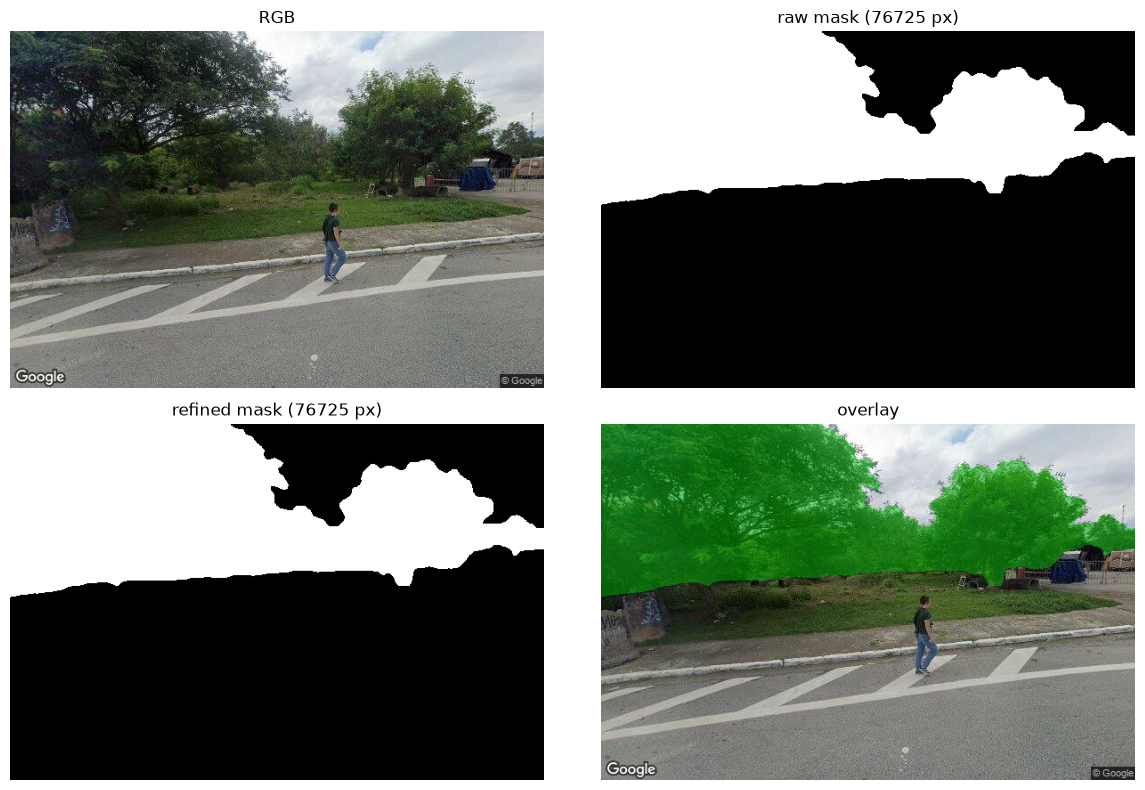

refinement: {'enabled': True, 'area_raw': 76725, 'area_refined': 76725, 'components_removed': 0, 'holes_filled': 0, 'area_growth_frac': 0.0, 'growth_guard_triggered': False, 'config': {'enabled': True, 'min_component_area_px': 64, 'min_component_area_frac': None, 'max_hole_area_px': 64, 'open_kernel_px': 0, 'close_kernel_px': 0, 'max_area_growth_frac': 0.05}}


In [6]:
raw = result.raw_mask.astype(bool)
refined = result.refined_mask.astype(bool)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0, 0].imshow(rgb);                axes[0, 0].set_title("RGB")
axes[0, 1].imshow(raw, cmap="gray");   axes[0, 1].set_title(f"raw mask ({raw.sum()} px)")
axes[1, 0].imshow(refined, cmap="gray"); axes[1, 0].set_title(f"refined mask ({refined.sum()} px)")

overlay = rgb.copy()
overlay[refined] = (0.45 * np.array([0, 200, 0]) + 0.55 * overlay[refined]).astype("uint8")
axes[1, 1].imshow(overlay);            axes[1, 1].set_title("overlay")

for ax in axes.ravel():
    ax.axis("off")
plt.tight_layout()
plt.show()

print("refinement:", result.refinement.to_dict())

## Does refinement change the answer?

Refinement here is deliberately timid -- remove specks, close pinholes -- and it
carries a growth guard that rolls back any setting which would inflate the mask
by more than a set fraction. Filling the gaps between branches would raise the
coverage number without any tree being there, which is the failure mode the
whole module is designed around.

Comparing against `enabled=False` is the baseline any refinement experiment
should report.

In [7]:
from urban_canopy.processing.refinement import RefinementConfig

raw_pipeline = CanopyPipeline(
    segmenter=segmenter,
    config=CanopyConfig(refinement=RefinementConfig(enabled=False)),
)
unrefined = raw_pipeline.analyse_image(image_path)

a = unrefined.coverage.tree_coverage_pct
b = result.coverage.tree_coverage_pct
print(f"refinement off : {a:.2f}%")
print(f"refinement on  : {b:.2f}%")
print(f"difference     : {b - a:+.2f} pp")

refinement off : 31.97%
refinement on  : 31.97%
difference     : +0.00 pp


A difference of zero is the expected outcome on a clean mask, and is worth
seeing: the defaults drop components under 64 px and fill holes under 64 px, and
one large well-formed crown has neither. Refinement exists for speckled
predictions, not to improve good ones.

### The growth guard

Aggressive settings are where refinement becomes dangerous, because welding
crowns together and bridging the sky between branches *raises the coverage
number without any tree being there*. The guard rolls the additive steps back
when they inflate the mask beyond `max_area_growth_frac`.

Watch it on two images with the same aggressive closing kernel: the dense frame
above, and the sparsest frame in the sample set (0.8% coverage, a handful of
small fragments).

In [8]:
sparse_path = SAMPLES / "streetview_id1_heading90.jpg"

aggressive = CanopyPipeline(
    segmenter=segmenter,
    config=CanopyConfig(
        refinement=RefinementConfig(close_kernel_px=25, max_area_growth_frac=0.05)
    ),
)

for label, path in [("dense  (36% canopy)", image_path), ("sparse (0.8% canopy)", sparse_path)]:
    plain = pipeline.analyse_image(path)
    forced = aggressive.analyse_image(path)
    ref = forced.refinement
    print(
        f"{label}: {plain.coverage.tree_coverage_pct:6.2f}% -> "
        f"{forced.coverage.tree_coverage_pct:6.2f}%  "
        f"growth={ref.area_growth_frac:+.3f}  guard_fired={ref.growth_guard_triggered}"
    )

dense  (36% canopy):  31.97% ->  32.55%  growth=+0.018  guard_fired=False


sparse (0.8% canopy):   0.80% ->   0.80%  growth=-0.001  guard_fired=True


On the dense mask the closing adds a couple of percent — under the 5% limit, so
it is allowed through: the guard is a bound on inflation, not a ban on any
change. On the sparse mask the same kernel would have ballooned a few fragments
into a solid blob, the guard fires, and the reported coverage stays put.

That asymmetry is the point. Proportional inflation is worst exactly where the
signal is weakest, which is where an unnoticed post-processing artifact would do
the most damage to a study.

## The same thing from the command line

```bash
tree-ai --image samples/images/streetview_id1_heading0.jpg --save-artifacts
```

One flag writes the whole bundle: a run directory under `artifacts_out/` with
the RGB frame, both masks, the overlay and a `metrics.json` per view, plus
`run.json`, `views.csv` and `predictions.json` for the run. Each invocation
gets its own directory, so running a second backend on the same image does
not overwrite the first.

**Next:** `02_multiview_and_evaluation.ipynb` -- why one heading is not a
property of a location, and how the three evaluation levels work.